# Study 6 ablations: literal listener & distance-blind null vs the full GP + RSA model

Two ablations of the full 4-D fit (`model-study6-vbmc-laplace-beta.ipynb`), each refit to the
study 6 data with the same spec (Laplace + VBMC, fitted linking shapes, fitted beta, widened
beta bound, 2d embedding; fits produced by `fit_study6_ablation.py`):

- **no-transfer null**: EVERY condition loses its utterances — no channel from statements to
  the (unmentioned) test features, so predictions cannot differ by condition. This is the
  analog of the collaborator's base model ("reasoning about individuals and features only");
  per-feature variation survives via the profiled linking shapes. ls pinned, beta dropped
  (k=2: mu_0, sigma).
- **literal (specifics dropped)**: specific statements carry ZERO evidence (dropped from the
  utterance set; generics keep the RSA speaker, beta fitted). Removes exactly the pragmatic
  "could have said the generic but chose not to" inference.
- **literal (aligned semantics)**: the faithful in-framework translation of the gorgo
  literal listener (`model/model.py`) — ALL utterances kept, likelihood = literal
  truth-conditioning with 5% misspeak noise (`speaker='literal'`,
  `model_jax.p_u_given_y_literal`). Specifics are vacuously true -> zero evidence by
  semantics rather than deletion (verified equivalent to machine precision); generics carry
  the fixed 19:1 truth ratio. No speaker -> no beta -> k=3.
- **distance-blind null**: length scale pinned at `LS_FLAT=10` (~13x the set1 cloud diameter,
  kernel effectively constant), 3 free params (mu_0, sigma, beta). Tests the GP feature-space
  component specifically; category-coherence reasoning and pragmatics stay intact. NOTE this is
  the study-9-style structure null, NOT the collaborator's "individuals only" base model.

All predictions below are **ratings-free** (coherence inferred from utterances only).

In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ.setdefault("JAX_ENABLE_X64", "1")

import sys
sys.path.insert(0, ".")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax.numpy as jnp

import inference as inf
import studies68 as s68

inf.set_embed('2d')
RESULTS_DIR = os.path.join('results', 'study6-ablations')
FULL_DIR    = os.path.join('results', 'study6-vbmc-laplace-beta')

geom_full, responses_cond = s68.load_study6()
J, test_feature_names = geom_full['J'], geom_full['test_feature_names']
CONDS = list(responses_cond.keys())
emp_cond = {c: np.array(responses_cond[c]).mean(0) for c in CONDS}

geom_lit = s68.load_study6()[0]
geom_lit['x_train_cond']['specific'] = jnp.zeros((0, 2))
geom_lit['u_train_cond']['specific'] = jnp.zeros(0, dtype=jnp.int32)
geom_lit['train_names_cond']['specific'] = []

geom_nt = s68.load_study6()[0]
for c in list(geom_nt['x_train_cond']):
    geom_nt['x_train_cond'][c] = jnp.zeros((0, 2))
    geom_nt['u_train_cond'][c] = jnp.zeros(0, dtype=jnp.int32)
    geom_nt['train_names_cond'][c] = []

geom_sem = s68.load_study6()[0]
geom_sem['speaker'] = 'literal'   # truth-conditional likelihood, all utterances kept

def load_fit(path):
    z = np.load(path, allow_pickle=True)
    fit = {k: z[k] for k in ('ls_samples', 'mu0_samples', 'sigma_samples', 'beta_samples')}
    fit.update(json.loads(str(z['meta'])))
    return fit

MODELS = {
    'null (no transfer)':    dict(fit=load_fit(os.path.join(RESULTS_DIR, 'posterior-notransfer.npz')),
                                  geom=geom_nt, n_params=2),
    'null (distance-blind)': dict(fit=load_fit(os.path.join(RESULTS_DIR, 'posterior-null.npz')),
                                  geom=geom_full, n_params=3),
    'literal (specifics dropped)': dict(fit=load_fit(os.path.join(RESULTS_DIR, 'posterior-literal.npz')),
                                        geom=geom_lit, n_params=4),
    'literal (aligned semantics)': dict(fit=load_fit(os.path.join(RESULTS_DIR, 'posterior-literalsem.npz')),
                                        geom=geom_sem, n_params=3),
    'full (pragmatic)':      dict(fit=load_fit(os.path.join(FULL_DIR, 'posterior-fitted-shapes.npz')),
                                  geom=geom_full, n_params=4),
}
for name, m in MODELS.items():
    print(f"{name:<22} convergence={m['fit']['convergence_status']}  "
          f"evals={m['fit']['func_count']}  ELBO={m['fit']['elbo']:.1f}")

null (no transfer)     convergence=probable  evals=305  ELBO=1402.0
null (distance-blind)  convergence=probable  evals=285  ELBO=1426.5
literal (specifics dropped) convergence=no  evals=400  ELBO=1416.4
literal (aligned semantics) convergence=probable  evals=180  ELBO=1416.7
full (pragmatic)       convergence=probable  evals=295  ELBO=1428.3


## Forward passes and comparison table

Each model's ratings-free predictions at its own posterior median, with its own profiled
linking shapes. The comparison column is the CONDITIONAL ratings likelihood
`log p(ratings | utterances)` (`inference.conditional_ratings_log_lik`) — raw summed log Z is
NOT comparable across these models because they condition on different utterance sets (a model
that drops or neuters utterances stops paying their log p(u) terms). Alongside the parameter
counts it plays the AIC-ish role of the R pipeline's `glmmTMB` comparison until the
collaborator runs the real one on the exported CSVs.

In [2]:
results = {}
for name, m in MODELS.items():
    f = m['fit']
    ls, mu, sig, beta = (float(np.median(f['ls_samples'])), float(np.median(f['mu0_samples'])),
                         float(np.median(f['sigma_samples'])), float(np.median(f['beta_samples'])))
    _, shapes, _ = inf.total_log_lik_free_shapes(m['geom'], responses_cond, ls, mu, sig,
                                                 beta_speaker=beta, return_shapes=True)
    cll = inf.conditional_ratings_log_lik(m['geom'], responses_cond, ls, mu, sig,
                                          beta_speaker=beta)
    mean_kl  = shapes[:, 0] / (shapes[:, 0] + shapes[:, 1])
    mean_nkl = shapes[:, 2] / (shapes[:, 2] + shapes[:, 3])
    pz1 = inf.prior_pz1_modes(m['geom'], ls, mu, sig, beta_speaker=beta)
    pred = {c: np.asarray(pz1[c]) * mean_kl + (1 - np.asarray(pz1[c])) * mean_nkl for c in CONDS}
    allp = np.concatenate([pred[c] for c in CONDS])
    alle = np.concatenate([emp_cond[c] for c in CONDS])
    results[name] = dict(theta=(ls, mu, sig, beta), cll=cll, pred=pred,
                         r2=np.corrcoef(allp, alle)[0, 1] ** 2)

print(f"{'model':<28}{'k':>3}{'ls':>8}{'mu_0':>8}{'sigma':>8}{'beta':>9}"
      f"{'logp(r|u)':>12}{'r2/feat':>9}")
for name, r in results.items():
    ls, mu, sig, beta = r['theta']
    print(f"{name:<28}{MODELS[name]['n_params']:>3}{ls:>8.2f}{mu:>8.2f}{sig:>8.2f}"
          f"{beta:>9.1f}{r['cll']:>12.1f}{r['r2']:>9.2f}")
print()
print(f"{'model':<28}" + ''.join(f"{c:>12}" for c in CONDS) + "   (predicted condition means)")
print(f"{'human':<28}" + ''.join(f"{float(np.array(responses_cond[c]).mean()):>12.3f}" for c in CONDS))
for name, r in results.items():
    print(f"{name:<28}" + ''.join(f"{r['pred'][c].mean():>12.3f}" for c in CONDS))

model                         k      ls    mu_0   sigma     beta   logp(r|u)  r2/feat
null (no transfer)            2   10.00   -0.24    2.10      3.0      1404.4     0.52
null (distance-blind)         3   10.00   -0.53    4.59      7.1      1438.4     0.89
literal (specifics dropped)   4    1.96   -1.43    1.85     15.7      1427.8     0.80
literal (aligned semantics)   3    1.48   -1.37    1.55      nan      1426.8     0.80
full (pragmatic)              4    2.47   -0.53    3.15      9.0      1440.6     0.89

model                            generic    specific    baseline   (predicted condition means)
human                              0.446       0.260       0.360
null (no transfer)                 0.374       0.374       0.374
null (distance-blind)              0.480       0.277       0.371
literal (specifics dropped)        0.480       0.324       0.324
literal (aligned semantics)        0.486       0.323       0.323
full (pragmatic)                   0.480       0.277       0.36

## Three-panel model-vs-data figure (Exp-1a slide format)

Same visual language and progression as the collaborator's results slide — null (no transfer) |
literal | pragmatic — x = model prevalence, y = human prevalence, small dots = condition x
feature cells, large dots = condition means. The distance-blind null is deliberately NOT
plotted (it answers the orthogonal feature-geometry question and visually duplicates the full
model here); it remains in the comparison table above. The literal panel is the diagnostic
one: with specifics carrying no evidence, its blue (specific) mean must sit on top of the
green (baseline) mean on the model axis — the miss the pragmatic model fixes.

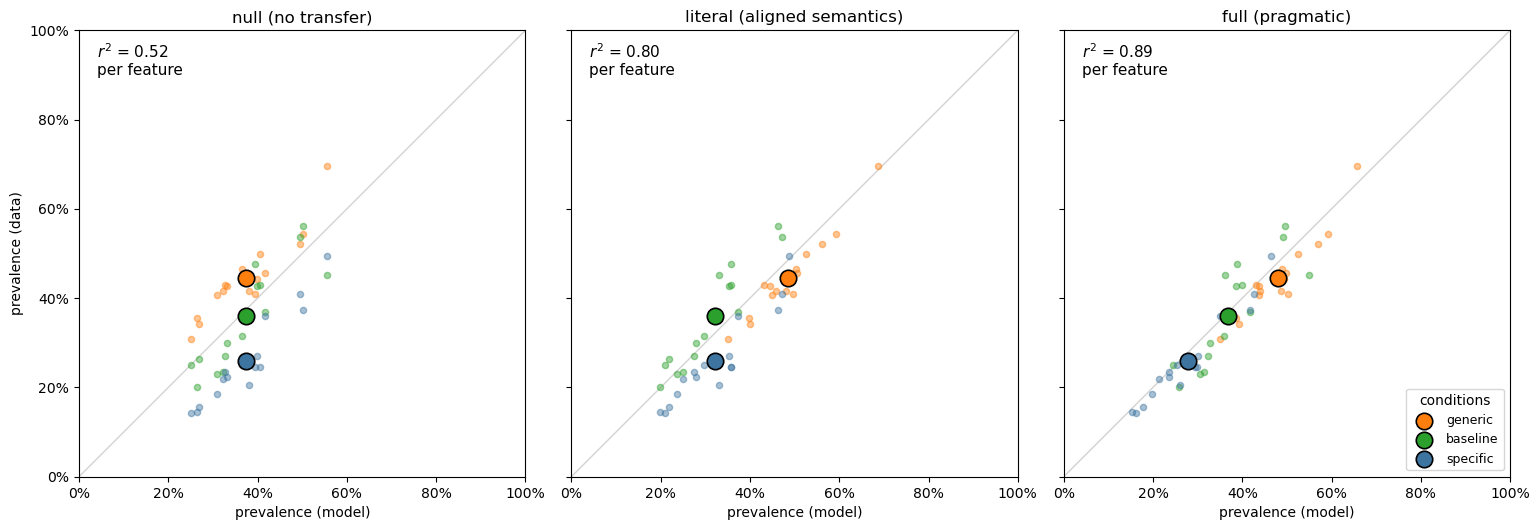

In [3]:
COND_ORDER = ['generic', 'baseline', 'specific']
COND_COLOR = {'generic': 'tab:orange', 'baseline': 'tab:green', 'specific': '#3d74a0'}
PLOT_MODELS = ['null (no transfer)', 'literal (aligned semantics)', 'full (pragmatic)']

fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.4), sharex=True, sharey=True)
for ax, name in zip(axes, PLOT_MODELS):
    r = results[name]
    ax.plot([0, 1], [0, 1], color='lightgray', lw=1, zorder=0)
    for c in COND_ORDER:
        ax.scatter(r['pred'][c], emp_cond[c], s=20, color=COND_COLOR[c], alpha=0.45, zorder=2)
        ax.scatter(r['pred'][c].mean(), emp_cond[c].mean(), s=140, color=COND_COLOR[c],
                   edgecolor='k', linewidth=1.2, zorder=3, label=c)
    ax.text(0.04, 0.90, f"$r^2$ = {r['r2']:.2f}\nper feature", transform=ax.transAxes, fontsize=11)
    ticks = np.linspace(0, 1, 6)
    ax.set_xticks(ticks); ax.set_xticklabels([f'{t:.0%}' for t in ticks])
    ax.set_yticks(ticks); ax.set_yticklabels([f'{t:.0%}' for t in ticks])
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
    ax.set_xlabel('prevalence (model)'); ax.set_title(name)
axes[0].set_ylabel('prevalence (data)')
axes[-1].legend(title='conditions', fontsize=9, loc='lower right')
plt.tight_layout(); plt.show()

## Export for the R pipeline

Ablation predictions in the `df_prag_feature.csv` schema (condition, snake_case feature,
prevalence), written to `results/study6-ablations/` and `model/scratch/study 6/`, next to
the full model's `df_gp_feature.csv`.

In [4]:
col_of_feature = {v: k for k, v in s68.STUDY6_COL_TO_FEATURE.items()}
scratch_dir = os.path.join('..', 'scratch', 'study 6')
os.makedirs(scratch_dir, exist_ok=True)
for name, fname in [('null (no transfer)', 'df_gp_notransfer_feature.csv'),
                    ('null (distance-blind)', 'df_gp_null_feature.csv'),
                    ('literal (specifics dropped)', 'df_gp_lit_feature.csv'),
                    ('literal (aligned semantics)', 'df_gp_litsem_feature.csv')]:
    pred = results[name]['pred']
    export = pd.DataFrame([
        {'condition': c, 'feature': col_of_feature[f], 'prevalence': float(pred[c][j])}
        for c in COND_ORDER for j, f in enumerate(test_feature_names)])
    export.to_csv(os.path.join(RESULTS_DIR, fname), index=False)
    export.to_csv(os.path.join(scratch_dir, fname), index=False)
    print(f"saved {fname} to {RESULTS_DIR}/ and {scratch_dir}/")

saved df_gp_notransfer_feature.csv to results/study6-ablations/ and ../scratch/study 6/
saved df_gp_null_feature.csv to results/study6-ablations/ and ../scratch/study 6/
saved df_gp_lit_feature.csv to results/study6-ablations/ and ../scratch/study 6/
saved df_gp_litsem_feature.csv to results/study6-ablations/ and ../scratch/study 6/
